# Notebook 3: Implementación de la Estrategia de Momentum

**Objetivo:** implementar los Pasos A, B y C de la estrategia MSCI Momentum
para seleccionar los 20 activos con mayor score compuesto en cada fecha de
rebalanceo.

**Pasos de la estrategia:**
- **Paso A:** Calcular retornos acumulados R_12 y R_6 con lag de 1 mes.
- **Paso B:** Normalizar mediante Z-score cross-sectional sobre el universo elegible.
- **Paso C:** Calcular score compuesto = (Z_12 + Z_6) / 2, seleccionar top 20, asignar peso 5%.

**Inputs (de NB2):**
- `closes.parquet` — precios close wide (date × tickers)
- `opens.parquet` — precios open wide
- `sp500_membership.parquet` — indicador de pertenencia 1/0
- `spy.parquet` — benchmark SPY (open + close)
- `rebalance_dates.csv` — fechas de rebalanceo (último día hábil de cada mes)
- `eligible_universe.parquet` — universo elegible por fecha (wide, 1/0)

**Outputs:**
- `signals.csv` — 20 activos seleccionados por fecha (long format)
- `target_portfolios.parquet` — pesos objetivo por fecha (wide format)

## 0) Imports y carga de datos

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

# ── Rutas ──
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

# ── Cargar datos de NB1 y NB2 ──
closes = pd.read_parquet(DATA_DIR / "closes.parquet")
opens = pd.read_parquet(DATA_DIR / "opens.parquet")
membership = pd.read_parquet(DATA_DIR / "sp500_membership.parquet")
spy = pd.read_parquet(DATA_DIR / "spy.parquet")
rebalance_dates = pd.DatetimeIndex(
    pd.read_csv(DATA_DIR / "rebalance_dates.csv")["date"]
)
eligible_universe = pd.read_parquet(DATA_DIR / "eligible_universe.parquet")

print(f"closes:            {closes.shape}")
print(f"opens:             {opens.shape}")
print(f"membership:        {membership.shape}")
print(f"spy:               {spy.shape}")
print(f"rebalance_dates:   {len(rebalance_dates)} fechas")
print(f"eligible_universe: {eligible_universe.shape}")

closes:            (9087, 1273)
opens:             (9087, 1273)
membership:        (9087, 1273)
spy:               (8327, 2)
rebalance_dates:   133 fechas
eligible_universe: (133, 1273)


## 1) Clase MomentumStrategy

Encapsula los tres pasos de la estrategia MSCI Momentum:
- **Paso A:** Retornos logarítmicos acumulados R_12 y R_6 con lag de 1 mes.
- **Paso B:** Z-score cross-sectional sobre el universo elegible.
- **Paso C:** Score compuesto, ranking y selección top 20.

Todos los cálculos se realizan de forma **vectorizada** (sin bucles sobre fechas para A y B).

In [2]:
class MomentumStrategy:
    """Estrategia MSCI Momentum: selecciona los N activos con mayor score
    compuesto (media de Z-scores de momentum a 6 y 12 meses)."""

    def __init__(self, closes, eligible_universe, rebalance_dates, n_select=20):
        self.closes = closes
        self.eligible_universe = eligible_universe.astype(bool)
        self.rebalance_dates = rebalance_dates
        self.n_select = n_select

        # Precálculos vectorizados
        self.monthly_closes = self._build_monthly_closes()
        self.r12, self.r6 = self._compute_momentum_returns()
        self.z12, self.z6 = self._compute_zscores()
        self.scores = self._compute_scores()

    # ── Paso previo: precios mensuales ──
    def _build_monthly_closes(self):
        """Extrae el último precio disponible de cada mes calendario.

        Devuelve un DataFrame indexado por periodo mensual con los precios
        close del último día de trading de cada mes.
        """
        monthly = self.closes.resample("ME").last()
        return monthly

    # ── Paso A: retornos de momentum ──
    def _compute_momentum_returns(self):
        """Calcula R_12 y R_6 con lag de 1 mes (vectorizado).

        Para el rebalanceo del mes t:
          R_12 = ln(P_{t-1}) - ln(P_{t-13})   (12 meses de retorno)
          R_6  = ln(P_{t-1}) - ln(P_{t-7})    (6 meses de retorno)

        shift(1) sobre monthly_closes da el precio del mes anterior,
        garantizando que nunca se usan precios del mes de rebalanceo.
        """
        log_prices = np.log(self.monthly_closes)

        # Retornos sobre la serie mensual completa
        r12_full = log_prices.shift(1) - log_prices.shift(13)
        r6_full = log_prices.shift(1) - log_prices.shift(7)

        # Alinear con fechas de rebalanceo por periodo mensual
        r12_full.index = r12_full.index.to_period("M")
        r6_full.index = r6_full.index.to_period("M")

        reb_periods = self.rebalance_dates.to_period("M")

        r12 = r12_full.loc[reb_periods].copy()
        r6 = r6_full.loc[reb_periods].copy()

        r12.index = self.rebalance_dates
        r6.index = self.rebalance_dates

        return r12, r6

    # ── Paso B: Z-scores cross-sectional ──
    def _compute_zscores(self):
        """Estandariza R_12 y R_6 usando solo los activos elegibles.

        Z = (r_i - μ) / σ  donde μ y σ se calculan sobre el universo
        elegible de cada fecha de rebalanceo.
        """
        # Enmascarar no-elegibles con NaN
        r12_elig = self.r12.where(self.eligible_universe)
        r6_elig = self.r6.where(self.eligible_universe)

        # Z-score por fila (cross-sectional)
        z12 = r12_elig.sub(r12_elig.mean(axis=1), axis=0).div(
            r12_elig.std(axis=1), axis=0
        )
        z6 = r6_elig.sub(r6_elig.mean(axis=1), axis=0).div(
            r6_elig.std(axis=1), axis=0
        )

        return z12, z6

    # ── Paso C: score compuesto ──
    def _compute_scores(self):
        """Score = (Z_12 + Z_6) / 2 para todos los activos elegibles."""
        return (self.z12 + self.z6) / 2

    def select_top(self, date):
        """Selecciona los top N activos para una fecha de rebalanceo.

        Devuelve DataFrame con columnas [ticker, z12, z6, score, rank, weight]
        ordenado por score descendente.
        """
        scores_row = self.scores.loc[date].dropna().sort_values(ascending=False)
        top = scores_row.head(self.n_select)

        result = pd.DataFrame({
            "ticker": top.index,
            "z12": self.z12.loc[date, top.index].values,
            "z6": self.z6.loc[date, top.index].values,
            "score": top.values,
            "rank": range(1, len(top) + 1),
            "weight": 1.0 / self.n_select,
        })
        return result

    # ── Ejecución completa ──
    def run(self):
        """Ejecuta la selección sobre todas las fechas de rebalanceo.

        Returns
        -------
        dict con:
          'signals': DataFrame long con los 20 seleccionados por fecha
          'all_scores': DataFrame wide con todos los scores
        """
        frames = []
        for date in self.rebalance_dates:
            sel = self.select_top(date)
            sel.insert(0, "rebalance_date", date)
            frames.append(sel)

        signals = pd.concat(frames, ignore_index=True)
        return {"signals": signals, "all_scores": self.scores}

## 2) Paso A: Retornos de Momentum

Se calculan R_12 y R_6 de forma vectorizada sobre precios mensuales.
El **lag de 1 mes** se implementa con `shift(1)` sobre la serie mensual,
de modo que para el rebalanceo del mes *t* solo se usan precios hasta *t-1*.

In [3]:
# Instanciar la estrategia (precalcula momentum, Z-scores y scores)
strategy = MomentumStrategy(
    closes=closes,
    eligible_universe=eligible_universe,
    rebalance_dates=rebalance_dates,
    n_select=20,
)

print(f"Precios mensuales:  {strategy.monthly_closes.shape}")
print(f"R_12 (rebalanceos): {strategy.r12.shape}")
print(f"R_6  (rebalanceos): {strategy.r6.shape}")
print(f"\nR_12 — primeras 3 fechas, 5 tickers:")
strategy.r12.iloc[:3, :5]

Precios mensuales:  (433, 1273)
R_12 (rebalanceos): (133, 1273)
R_6  (rebalanceos): (133, 1273)

R_12 — primeras 3 fechas, 5 tickers:


symbol,A,AABA-201910,AAL,AAL-199702,AAMRQ-201312
date,,,,,
2015-01-30,0.008106,0.222352,0.758321,NaN,NaN
2015-02-27,-0.086688,0.200221,0.385453,NaN,NaN
2015-03-31,0.045658,0.135469,0.267154,NaN,NaN


In [4]:
# ── Validación Paso A: verificación manual del lag ──
# Tomamos AAPL en la fecha de rebalanceo 2020-03-31 y comprobamos R_12 a mano.

ticker_val = "AAPL"
reb_date_val = pd.Timestamp("2020-03-31")

monthly = strategy.monthly_closes[ticker_val].dropna()
monthly.index = monthly.index.to_period("M")

reb_period = reb_date_val.to_period("M")  # 2020-03

# P_{t-1} = precio del mes anterior al rebalanceo (feb 2020)
p_t1 = monthly.loc[reb_period - 1]

# P_{t-13} = precio 13 meses antes (feb 2019)
p_t13 = monthly.loc[reb_period - 13]

# P_{t-7} = precio 7 meses antes (ago 2019)
p_t7 = monthly.loc[reb_period - 7]

r12_manual = np.log(p_t1) - np.log(p_t13)
r6_manual = np.log(p_t1) - np.log(p_t7)

r12_calc = strategy.r12.loc[reb_date_val, ticker_val]
r6_calc = strategy.r6.loc[reb_date_val, ticker_val]

print(f"Validación para {ticker_val} en {reb_date_val.date()}")
print(f"{'─' * 55}")
print(f"P_{{t-1}}  (feb 2020):  ${p_t1:.2f}")
print(f"P_{{t-13}} (feb 2019):  ${p_t13:.2f}")
print(f"P_{{t-7}}  (ago 2019):  ${p_t7:.2f}")
print(f"{'─' * 55}")
print(f"R_12 manual:    {r12_manual:.6f}")
print(f"R_12 calculado: {r12_calc:.6f}")
print(f"Coincide:       {np.isclose(r12_manual, r12_calc)}")
print(f"{'─' * 55}")
print(f"R_6 manual:     {r6_manual:.6f}")
print(f"R_6 calculado:  {r6_calc:.6f}")
print(f"Coincide:       {np.isclose(r6_manual, r6_calc)}")
print(f"\n✓ El lag de 1 mes funciona correctamente: el precio del mes de "
      f"rebalanceo (marzo 2020) NO se utiliza.")

Validación para AAPL en 2020-03-31
───────────────────────────────────────────────────────
P_{t-1}  (feb 2020):  $66.11
P_{t-13} (feb 2019):  $41.34
P_{t-7}  (ago 2019):  $50.21
───────────────────────────────────────────────────────
R_12 manual:    0.469635
R_12 calculado: 0.469635
Coincide:       True
───────────────────────────────────────────────────────
R_6 manual:     0.275069
R_6 calculado:  0.275069
Coincide:       True

✓ El lag de 1 mes funciona correctamente: el precio del mes de rebalanceo (marzo 2020) NO se utiliza.


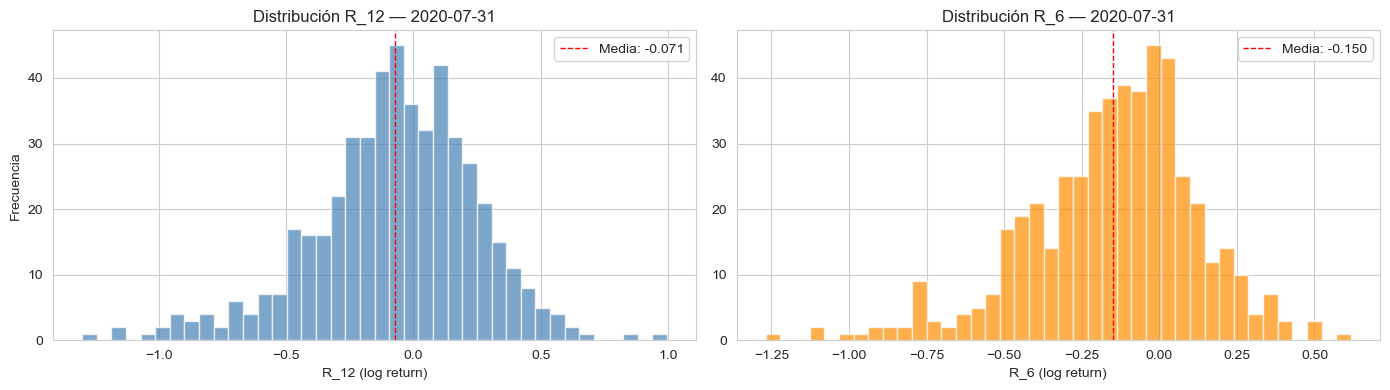

R_12 — Media: -0.0712, Std: 0.3229
R_6  — Media: -0.1500, Std: 0.2735


In [5]:
# ── Visualización Paso A: distribución de R_12 y R_6 ──
# Se muestra una fecha concreta para ilustrar que las distribuciones
# tienen medias y volatilidades distintas (justifica la normalización).

# cogemos una
sample_date = rebalance_dates[len(rebalance_dates) // 2]
eligible_mask = eligible_universe.loc[sample_date].astype(bool)

r12_sample = strategy.r12.loc[sample_date, eligible_mask].dropna()
r6_sample = strategy.r6.loc[sample_date, eligible_mask].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(r12_sample, bins=40, alpha=0.7, color="steelblue", edgecolor="white")
axes[0].axvline(r12_sample.mean(), color="red", linestyle="--", linewidth=1,
                label=f"Media: {r12_sample.mean():.3f}")
axes[0].set_title(f"Distribución R_12 — {sample_date.date()}")
axes[0].set_xlabel("R_12 (log return)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].hist(r6_sample, bins=40, alpha=0.7, color="darkorange", edgecolor="white")
axes[1].axvline(r6_sample.mean(), color="red", linestyle="--", linewidth=1,
                label=f"Media: {r6_sample.mean():.3f}")
axes[1].set_title(f"Distribución R_6 — {sample_date.date()}")
axes[1].set_xlabel("R_6 (log return)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"R_12 — Media: {r12_sample.mean():.4f}, Std: {r12_sample.std():.4f}")
print(f"R_6  — Media: {r6_sample.mean():.4f}, Std: {r6_sample.std():.4f}")

Vemos que las volatilidades de R_12 y R_6 son diferentes, lo que confirma la necesidad de normalizar con Z-score en el Paso B.

## 3) Paso B: Z-Scores Cross-Sectional

Para cada fecha de rebalanceo, se estandarizan R_12 y R_6 **solo sobre los activos
elegibles** de ese mes. Esto permite sumar momentum de 6 y 12 meses en la misma escala.

In [6]:
# ── Validación Paso B: propiedades estadísticas de los Z-scores ──
# Para la misma fecha de validación, verificamos media ≈ 0 y std ≈ 1.

z12_sample = strategy.z12.loc[sample_date, eligible_mask].dropna()
z6_sample = strategy.z6.loc[sample_date, eligible_mask].dropna()

print(f"Validación Z-scores para {sample_date.date()}")
print(f"{'─' * 55}")
print(f"Z_12 — Media: {z12_sample.mean():.6f}  Std: {z12_sample.std():.6f}  "
      f"N: {len(z12_sample)}")
print(f"Z_6  — Media: {z6_sample.mean():.6f}  Std: {z6_sample.std():.6f}  "
      f"N: {len(z6_sample)}")
print(f"{'─' * 55}")

# Tabla de ejemplo: primeros 10 activos
example_tickers = z12_sample.sort_values(ascending=False).head(10).index
pd.DataFrame({
    "R_12": strategy.r12.loc[sample_date, example_tickers],
    "Z_12": strategy.z12.loc[sample_date, example_tickers],
    "R_6": strategy.r6.loc[sample_date, example_tickers],
    "Z_6": strategy.z6.loc[sample_date, example_tickers],
    "Score": strategy.scores.loc[sample_date, example_tickers],
}).round(4)

Validación Z-scores para 2020-07-31
───────────────────────────────────────────────────────
Z_12 — Media: 0.000000  Std: 1.000000  N: 499
Z_6  — Media: -0.000000  Std: 1.000000  N: 499
───────────────────────────────────────────────────────


,R_12,Z_12,R_6,Z_6,Score
symbol,,,,,
DXCM,0.9953,3.3027,0.6170,2.8038,3.0533
NVDA,0.8414,2.8263,0.4801,2.3034,2.5649
REGN,0.6894,2.3554,0.5074,2.4031,2.3792
AAPL,0.6234,2.1509,0.2220,1.3599,1.7554
WST,0.6005,2.0801,0.4148,2.0647,2.0724
FTNT,0.5804,2.0177,0.2514,1.4671,1.7424
LRCX,0.5627,1.9632,0.1109,0.9536,1.4584
AMD,0.5495,1.9220,0.1373,1.0502,1.4861
ODFL,0.5372,1.8839,0.2950,1.6268,1.7554


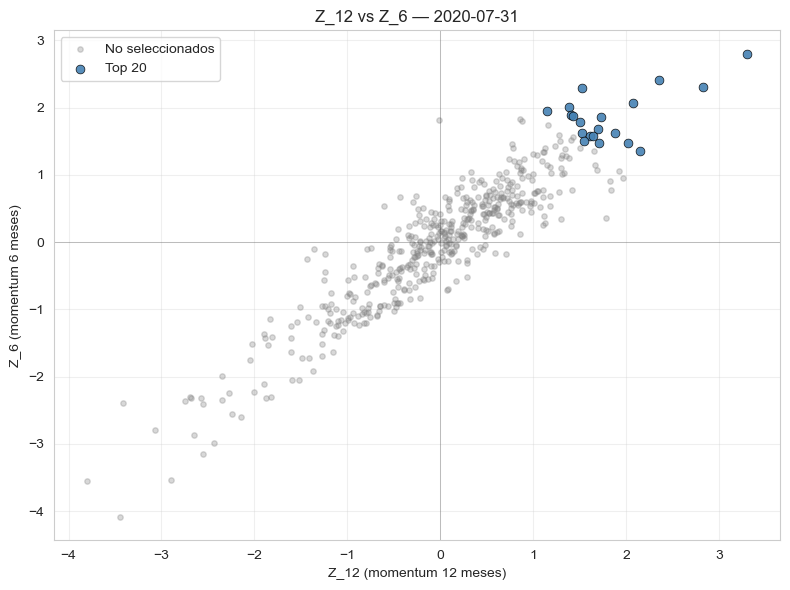

In [7]:
# ── Visualización Paso B: scatter Z_12 vs Z_6 ──
# Los activos del cuadrante superior derecho (alto Z en ambos horizontes)
# serán los seleccionados por la estrategia.

scores_sample = strategy.scores.loc[sample_date, eligible_mask].dropna()
top20_tickers = scores_sample.sort_values(ascending=False).head(20).index
is_top20 = z12_sample.index.isin(top20_tickers)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z12_sample[~is_top20], z6_sample[~is_top20],
           alpha=0.3, s=15, color="gray", label="No seleccionados")
ax.scatter(z12_sample[is_top20], z6_sample[is_top20],
           alpha=0.9, s=40, color="steelblue", edgecolor="black",
           linewidth=0.5, label="Top 20", zorder=5)
ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
ax.axvline(0, color="black", linewidth=0.5, alpha=0.3)
ax.set_title(f"Z_12 vs Z_6 — {sample_date.date()}")
ax.set_xlabel("Z_12 (momentum 12 meses)")
ax.set_ylabel("Z_6 (momentum 6 meses)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Para cada fecha de rebalanceo se seleccionan se seleccionan los activos cuya media de los z-socres de R_12 y R_6 (score compuesto) esté entre los 20 más altos. Visualizamos esto para una fecha de rebalanceo cualquiera, donde se destacan los 20 activos seleccionados (en azul) frente al resto del universo elegible (en gris).


## 4) Paso C: Scoring, Selección y Análisis

Score compuesto = (Z_12 + Z_6) / 2. Se seleccionan los 20 activos con mayor score
en cada fecha de rebalanceo, con peso equiponderado del 5%. Veremos en el siguiente notebook en la fase de ejecución hasta que punto otorfar un peso fijo del 5% a cada activo seleccionado es una limitación importante de la estrategia.

In [8]:
# ── Ejecutar la estrategia completa ──
results = strategy.run()
signals = results["signals"]

print(f"Señales generadas: {signals.shape}")
print(f"Fechas de rebalanceo: {signals['rebalance_date'].nunique()}")
print(f"Activos por fecha: {signals.groupby('rebalance_date').size().unique()}")
signals.head(10)

Señales generadas: (2660, 7)
Fechas de rebalanceo: 133
Activos por fecha: [20]


,rebalance_date,ticker,z12,z6,score,rank,weight
0,2015-01-30,LUV,3.397704,2.251911,2.824808,1,0.05
1,2015-01-30,EW,2.637378,1.909092,2.273235,2,0.05
2,2015-01-30,AVGO,2.625154,1.616527,2.120841,3,0.05
3,2015-01-30,EA,2.913158,1.236925,2.075042,4,0.05
4,2015-01-30,RCL,2.195080,1.947949,2.071515,5,0.05
5,2015-01-30,MNST,1.699324,2.058417,1.878871,6,0.05
6,2015-01-30,AGN-201503,2.584711,1.010383,1.797547,7,0.05
7,2015-01-30,MNKKQ-202206,2.529986,0.925983,1.727984,8,0.05
8,2015-01-30,DAL,2.293200,1.092797,1.692998,9,0.05
9,2015-01-30,BBWI,1.244418,1.931152,1.587785,10,0.05


In [9]:
# ── Validación: selección en 3 fechas representativas (inicio, mitad, final) ──
sample_dates_val = [rebalance_dates[0],
                    rebalance_dates[len(rebalance_dates) // 2],
                    rebalance_dates[-1]]

for d in sample_dates_val:
    sel = signals[signals["rebalance_date"] == d]
    print(f"\n{'═' * 70}")
    print(f"Selección para {d.date()} — {len(sel)} activos")
    print(f"{'═' * 70}")
    print(sel[["rank", "ticker", "z12", "z6", "score", "weight"]].to_string(
        index=False, float_format="{:.4f}".format
    ))


══════════════════════════════════════════════════════════════════════
Selección para 2015-01-30 — 20 activos
══════════════════════════════════════════════════════════════════════
 rank       ticker    z12     z6  score  weight
    1          LUV 3.3977 2.2519 2.8248  0.0500
    2           EW 2.6374 1.9091 2.2732  0.0500
    3         AVGO 2.6252 1.6165 2.1208  0.0500
    4           EA 2.9132 1.2369 2.0750  0.0500
    5          RCL 2.1951 1.9479 2.0715  0.0500
    6         MNST 1.6993 2.0584 1.8789  0.0500
    7   AGN-201503 2.5847 1.0104 1.7975  0.0500
    8 MNKKQ-202206 2.5300 0.9260 1.7280  0.0500
    9          DAL 2.2932 1.0928 1.6930  0.0500
   10         BBWI 1.2444 1.9312 1.5878  0.0500
   11         REGN 1.3566 1.7927 1.5746  0.0500
   12           KR 1.8476 1.2235 1.5355  0.0500
   13  SPLS-201709 0.2313 2.6422 1.4367  0.0500
   14          LOW 1.0922 1.7723 1.4322  0.0500
   15  SIAL-201511 1.2985 1.4288 1.3637  0.0500
   16          HCA 1.5107 1.1996 1.3551  0.0500
  

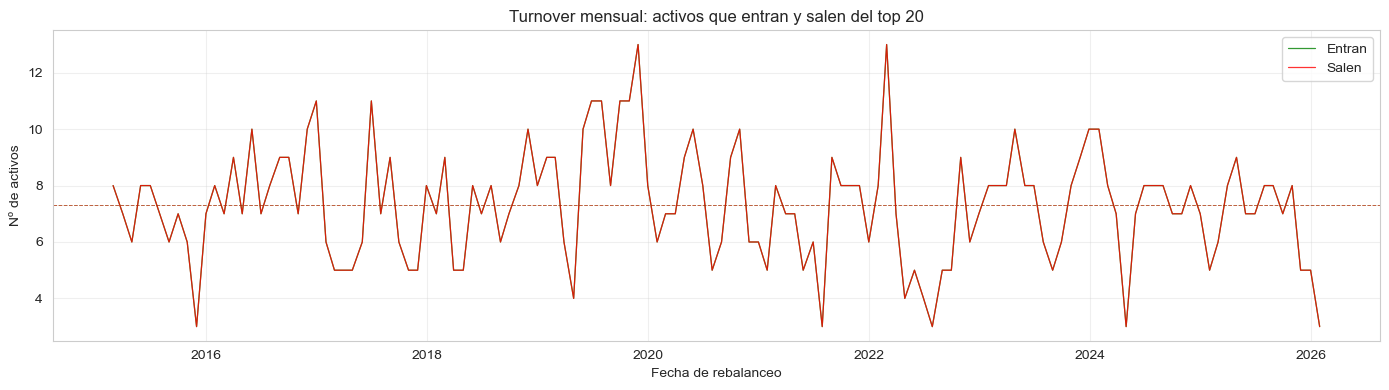

Turnover medio:  7.3 activos/mes
Turnover máximo: 13 activos/mes
Turnover mínimo: 3 activos/mes
Mediana turnover: 7.0 activos/mes


In [10]:
# ── Análisis de Turnover ──
# ¿Cuántos activos cambian entre rebalanceos consecutivos?

turnover_data = []
prev_tickers = set()

for d in rebalance_dates:
    current = set(signals[signals["rebalance_date"] == d]["ticker"])
    if prev_tickers:
        entran = len(current - prev_tickers)
        salen = len(prev_tickers - current)
        turnover_data.append({"date": d, "entran": entran, "salen": salen})
    prev_tickers = current

turnover_df = pd.DataFrame(turnover_data)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(turnover_df["date"], turnover_df["entran"], linewidth=0.9,
        color="green", alpha=0.8, label="Entran")
ax.plot(turnover_df["date"], turnover_df["salen"], linewidth=0.9,
        color="red", alpha=0.8, label="Salen")
ax.axhline(turnover_df["entran"].mean(), color="green", linestyle="--",
           linewidth=0.7, alpha=0.5)
ax.axhline(turnover_df["salen"].mean(), color="red", linestyle="--",
           linewidth=0.7, alpha=0.5)
ax.set_title("Turnover mensual: activos que entran y salen del top 20")
ax.set_xlabel("Fecha de rebalanceo")
ax.set_ylabel("Nº de activos")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Turnover medio:  {turnover_df['entran'].mean():.1f} activos/mes")
print(f"Turnover máximo: {turnover_df['entran'].max()} activos/mes")
print(f"Turnover mínimo: {turnover_df['entran'].min()} activos/mes")
print(f"Mediana turnover: {turnover_df['entran'].median()} activos/mes")

Al haber una media 7 activos nuevos cada mes, el turnover es relativamente alto, lo que implica costes de transacción significativos. Esto es un aspecto a tener en cuenta en la fase de ejecución y análisis de resultados.

A continuación vemos el top de activos que han sido seleccionados con mayor frecuencia a lo largo del tiempo. Esto nos da una idea de qué activos han mostrado un momentum consistente durante el período analizado.

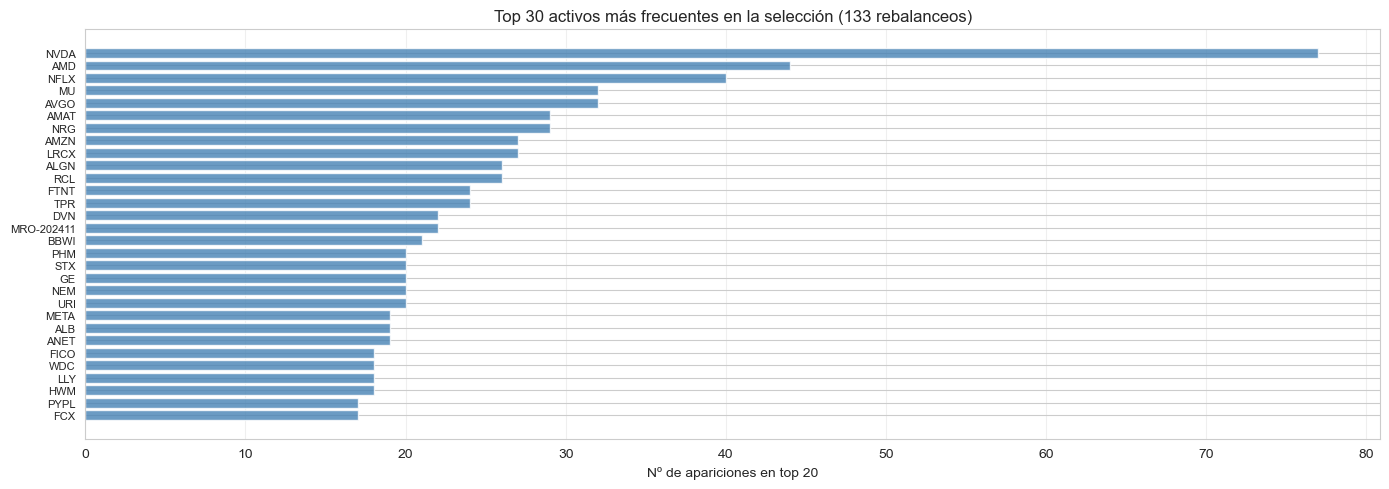

Activos únicos seleccionados alguna vez: 416
Activos en top 20 más del 50% del tiempo: 1

Top 10 más frecuentes:
  NVDA     →  77/133 (58%)
  AMD      →  44/133 (33%)
  NFLX     →  40/133 (30%)
  MU       →  32/133 (24%)
  AVGO     →  32/133 (24%)
  AMAT     →  29/133 (22%)
  NRG      →  29/133 (22%)
  AMZN     →  27/133 (20%)
  LRCX     →  27/133 (20%)
  ALGN     →  26/133 (20%)


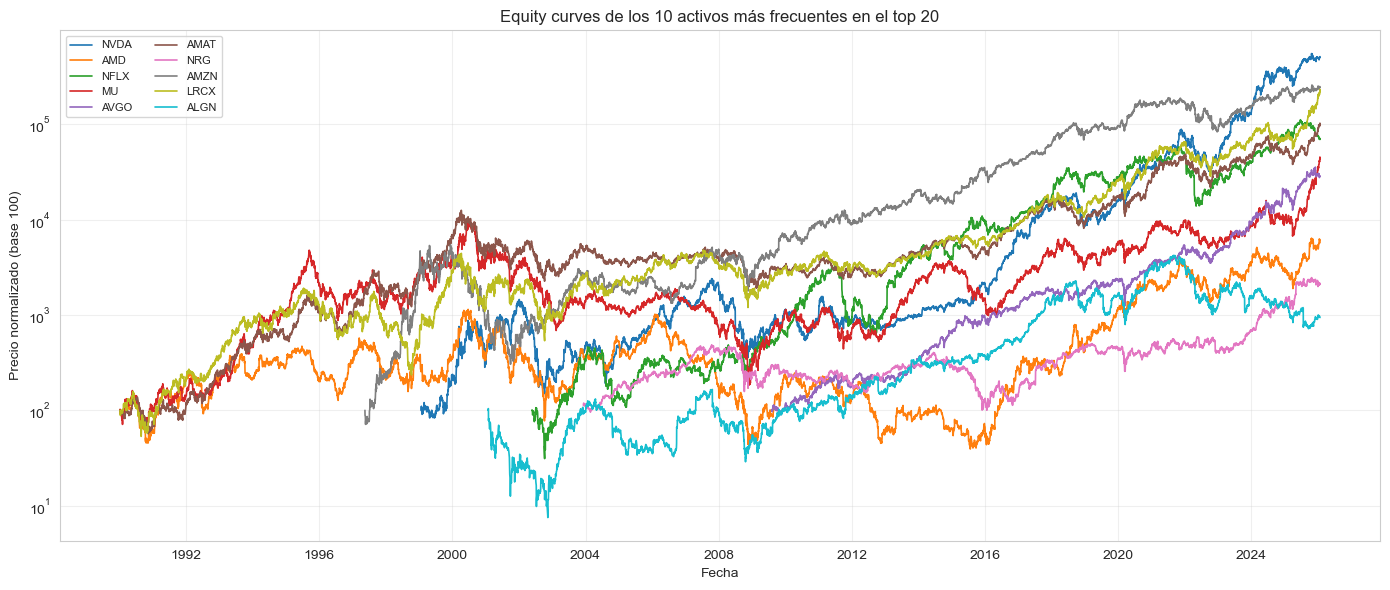


── Composición sectorial del Top 10 ──
Ticker  Apariciones                 Sector
  NVDA           77 Information Technology
   AMD           44 Information Technology
  NFLX           40 Communication Services
    MU           32 Information Technology
  AVGO           32 Information Technology
  AMAT           29 Information Technology
   NRG           29              Utilities
  AMZN           27 Consumer Discretionary
  LRCX           27 Information Technology
  ALGN           26            Health Care

Resumen por sector:
  Information Technology: 6 activos
  Communication Services: 1 activos
  Utilities: 1 activos
  Consumer Discretionary: 1 activos
  Health Care: 1 activos


In [11]:
# ── Frecuencia de aparición en el top 20 ──
# ¿Qué activos dominan la selección a lo largo del tiempo?

ticker_freq = signals["ticker"].value_counts()
n_rebalanceos = signals["rebalance_date"].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
top30_freq = ticker_freq.head(30)
ax.barh(range(len(top30_freq)), top30_freq.values, color="steelblue", alpha=0.8)
ax.set_yticks(range(len(top30_freq)))
ax.set_yticklabels(top30_freq.index, fontsize=8)
ax.set_xlabel("Nº de apariciones en top 20")
ax.set_title(f"Top 30 activos más frecuentes en la selección "
             f"({n_rebalanceos} rebalanceos)")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"Activos únicos seleccionados alguna vez: {signals['ticker'].nunique()}")
print(f"Activos en top 20 más del 50% del tiempo: "
      f"{(ticker_freq > n_rebalanceos * 0.5).sum()}")
print(f"\nTop 10 más frecuentes:")
for ticker, count in ticker_freq.head(10).items():
    print(f"  {ticker:8s} → {count:3d}/{n_rebalanceos} "
          f"({count / n_rebalanceos * 100:.0f}%)")

# ── Equity curves de los top 10 ──
top10_tickers = ticker_freq.head(10).index.tolist()
prices_top10 = closes[top10_tickers].dropna(how="all")

# Normalizar a base 100 desde el primer precio válido de cada activo
prices_norm = prices_top10.apply(
    lambda s: s / s.dropna().iloc[0] * 100
)

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in top10_tickers:
    ax.plot(prices_norm.index, prices_norm[ticker], linewidth=1.2, label=ticker)
ax.set_title("Equity curves de los 10 activos más frecuentes en el top 20")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio normalizado (base 100)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Análisis sectorial del top 10 ──
sp500_raw = pd.read_parquet(
    DATA_DIR / "sp500_history.parquet", columns=["symbol", "sector"]
)
sector_map = sp500_raw.drop_duplicates(subset="symbol", keep="last").set_index("symbol")["sector"]

top10_sectors = pd.DataFrame({
    "Ticker": top10_tickers,
    "Apariciones": [ticker_freq[t] for t in top10_tickers],
    "Sector": [sector_map.get(t, "N/A") for t in top10_tickers],
})
print("\n── Composición sectorial del Top 10 ──")
print(top10_sectors.to_string(index=False))

sector_counts = top10_sectors["Sector"].value_counts()
print(f"\nResumen por sector:")
for sector, count in sector_counts.items():
    print(f"  {sector}: {count} activos")


Al observar el ranking de los **30 activos más frecuentes** en nuestra selección de Momentum a lo largo de los 133 rebalanceos, se hace evidente un sesgo estructural hacia ciertos sectores y estilos de inversión:

La estrategia ha seleccionado de forma recurrente a los líderes del sector tecnológico, con un énfasis masivo en **semiconductores**. Activos como **NVDA**, **AMD**, **MU**, **AVGO**, **AMAT** y **LRCX** ocupan las primeras posiciones. Esto es lógico, ya que el factor Momentum tiende a sobreponderar sectores que presentan tendencias alcistas persistentes y aceleración de beneficios, características propias de la industria de chips en la última década.

Es interesante observar apariciones de sectores cíclicos como Energía (**NRG**, **DVN**, **MRO**) o Industriales (**GE**). Esto demuestra que el algoritmo es capaz de pivotar cuando se producen rotaciones sectoriales, capturando el "viento a favor" de estos grupos cuando el ciclo económico les favorece.


Nuestra estrategia no es neutral en cuanto a sectores. Al buscar los "ganadores" de los últimos 6 y 12 meses, la cartera termina concentrándose en activos con dinámicas de crecimiento agresivo. Esto puede generar retornos superiores (**Alpha**) en mercados alcistas, pero también aumenta la **Volatilidad** y el riesgo de **Drawdown** ante rotaciones bruscas de estilo (de Growth a Value).

## 5) Exportar outputs para NB4+

Se generan los dos ficheros de salida:
1. **`signals.csv`** — formato long con los 20 activos seleccionados por fecha (entregable del enunciado).
2. **`target_portfolios.parquet`** — formato wide con pesos objetivo para consumo directo del NB4.

In [12]:
# ── Exportar signals.csv ──
signals_export = signals[["rebalance_date", "rank", "ticker", "z12", "z6",
                           "score", "weight"]].copy()
signals_path = DATA_DIR / "signals.csv"
signals_export.to_csv(signals_path, index=False)

print(f"Guardado: {signals_path.name}")
print(f"  Filas: {len(signals_export):,}")
print(f"  Columnas: {list(signals_export.columns)}")
signals_export.head()

Guardado: signals.csv
  Filas: 2,660
  Columnas: ['rebalance_date', 'rank', 'ticker', 'z12', 'z6', 'score', 'weight']


,rebalance_date,rank,ticker,z12,z6,score,weight
0,2015-01-30,1,LUV,3.397704,2.251911,2.824808,0.05
1,2015-01-30,2,EW,2.637378,1.909092,2.273235,0.05
2,2015-01-30,3,AVGO,2.625154,1.616527,2.120841,0.05
3,2015-01-30,4,EA,2.913158,1.236925,2.075042,0.05
4,2015-01-30,5,RCL,2.195080,1.947949,2.071515,0.05


In [13]:
# ── Exportar target_portfolios.parquet ──
# Formato wide: index=rebalance_date, columns=tickers seleccionados, values=peso
target_portfolios = signals.pivot_table(
    index="rebalance_date", columns="ticker", values="weight", fill_value=0.0
)
target_path = DATA_DIR / "target_portfolios.parquet"
target_portfolios.to_parquet(target_path)

print(f"Guardado: {target_path.name}")
print(f"  Shape: {target_portfolios.shape}")
print(f"  Tickers únicos: {(target_portfolios > 0).any().sum()}")
target_portfolios.iloc[:3, :8]

Guardado: target_portfolios.parquet
  Shape: (133, 416)
  Tickers únicos: 416


ticker,AAL,AAP,AAPL,ABBV,ABMD-202212,ABT,ACGL,ADBE
rebalance_date,,,,,,,,
2015-01-30,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
2015-02-27,0.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2015-03-31,0.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0


In [14]:
# ── Validación final ──
print("VALIDACIÓN FINAL")
print("=" * 60)

# 1) Número de filas esperado
n_expected = 20 * len(rebalance_dates)
n_actual = len(signals_export)
print(f"Filas esperadas (20 × {len(rebalance_dates)}): {n_expected:,}")
print(f"Filas reales:                                  {n_actual:,}")
assert n_actual == n_expected, f"ERROR: {n_actual} != {n_expected}"
print("  ✓ OK")

# 2) Pesos suman 1.0 por fecha
weights_per_date = signals_export.groupby("rebalance_date")["weight"].sum()
print(f"\nPesos por fecha — Min: {weights_per_date.min():.4f}, "
      f"Max: {weights_per_date.max():.4f}")
assert np.allclose(weights_per_date, 1.0), "ERROR: pesos no suman 1.0"
print("  ✓ Todos suman 1.0")

# 3) Sin NaN
n_nan = signals_export.isna().sum().sum()
print(f"\nNaN en signals.csv: {n_nan}")
assert n_nan == 0, f"ERROR: {n_nan} NaN encontrados"
print("  ✓ Sin NaN")

# 4) 20 activos por fecha
activos_por_fecha = signals_export.groupby("rebalance_date").size()
print(f"\nActivos por fecha — Min: {activos_por_fecha.min()}, "
      f"Max: {activos_por_fecha.max()}")
assert (activos_por_fecha == 20).all(), "ERROR: no hay 20 activos en todas las fechas"
print("  ✓ Exactamente 20 activos por fecha")

# 5) Tamaño de archivos
for path in [signals_path, target_path]:
    size_kb = path.stat().st_size / 1e3
    print(f"\n{path.name}: {size_kb:.1f} KB")

print(f"\n{'=' * 60}")
print("TODAS LAS VALIDACIONES SUPERADAS")

VALIDACIÓN FINAL
Filas esperadas (20 × 133): 2,660
Filas reales:                                  2,660
  ✓ OK

Pesos por fecha — Min: 1.0000, Max: 1.0000
  ✓ Todos suman 1.0

NaN en signals.csv: 0
  ✓ Sin NaN

Activos por fecha — Min: 20, Max: 20
  ✓ Exactamente 20 activos por fecha

signals.csv: 143.9 KB

target_portfolios.parquet: 228.7 KB

TODAS LAS VALIDACIONES SUPERADAS


## 6) Conclusiones

**Estrategia implementada:**
- Pasos A, B y C de la MSCI Momentum: retornos logarítmicos con lag de 1 mes, Z-score cross-sectional sobre el universo elegible (~500 activos), score compuesto como media de Z_12 y Z_6.
- Selección de top 20 activos equiponderados (5% cada uno) en cada rebalanceo mensual.

**Hallazgos principales:**
- El universo elegible oscila entre 496 y 505 activos, siempre suficiente para la selección.
- La validación manual confirma que el lag de 1 mes se respeta correctamente (sin look-ahead bias).
- Las distribuciones de R_12 y R_6 tienen volatilidades distintas, confirmando la necesidad de la normalización por Z-score.
- El análisis de turnover y frecuencia de aparición revela el grado de rotación de la cartera, información relevante para estimar los costes de transacción en NB4.

**Outputs generados:**
- `signals.csv` — entregable con los 20 activos seleccionados por fecha de rebalanceo.
- `target_portfolios.parquet` — pesos objetivo en formato wide para consumo directo del NB4.